In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.inspection import permutation_importance

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

In [4]:
# Change this to your actual CSV filename
FILE_PATH = "instructor_effectiveness_dataset_2000_rows.csv"

df = pd.read_csv(FILE_PATH)

print("Dataset Shape:", df.shape)
display(df.head())

Dataset Shape: (2000, 12)


,batch_id,instructor_id,course_id,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate
0,B_1861,I_044,C_01,0.300000,14.225955,73.546528,0.647423,0.774572,0.790918,0.108414,3.766211,0.533193
1,B_0354,I_119,C_06,0.657220,22.871110,77.312331,0.425098,0.494936,0.998566,0.280550,5.000000,0.734087
2,B_1334,I_050,C_03,0.300000,16.087517,79.563687,0.700000,0.977901,0.807298,0.207013,3.517386,0.681433
3,B_0906,I_024,C_21,0.639507,24.260687,99.295316,0.334657,0.846515,0.544555,0.306395,4.207578,1.000000
4,B_1290,I_001,C_08,0.527302,31.081556,99.393425,0.521099,0.917450,0.865885,0.252289,4.426230,0.696710


In [5]:
print("Columns:")
print(df.columns.tolist())

print("\nData Types:")
display(df.dtypes)

print("\nBasic Statistics:")
display(df.describe(include="all").T)

print("\nNumber of unique instructors:", df["instructor_id"].nunique())
print("Number of unique courses:", df["course_id"].nunique())
print("Number of batches:", df["batch_id"].nunique())

Columns:
['batch_id', 'instructor_id', 'course_id', 'completion_rate', 'avg_score_improvement', 'avg_quiz_score', 'dropout_rate', 'avg_watch_time', 'assignment_submission_rate', 'forum_activity_rate', 'avg_feedback_score', 'feedback_response_rate']

Data Types:


batch_id                       object
instructor_id                  object
course_id                      object
completion_rate               float64
avg_score_improvement         float64
avg_quiz_score                float64
dropout_rate                  float64
avg_watch_time                float64
assignment_submission_rate    float64
forum_activity_rate           float64
avg_feedback_score            float64
feedback_response_rate        float64
dtype: object


Basic Statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
batch_id,2000,2000,B_1861,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
instructor_id,2000,120,I_062,31,NaN,NaN,NaN,NaN,NaN,NaN,NaN
course_id,2000,25,C_21,91,NaN,NaN,NaN,NaN,NaN,NaN,NaN
completion_rate,2000.0,NaN,NaN,NaN,0.602808,0.159667,0.3,0.48926,0.603091,0.712797,0.98
avg_score_improvement,2000.0,NaN,NaN,NaN,27.035844,5.716641,6.15924,23.124673,26.938629,30.8856,40.0
avg_quiz_score,2000.0,NaN,NaN,NaN,77.956126,10.695618,40.386725,70.89759,78.020567,85.444286,100.0
dropout_rate,2000.0,NaN,NaN,NaN,0.394883,0.162747,0.02,0.280035,0.39482,0.511432,0.7
avg_watch_time,2000.0,NaN,NaN,NaN,0.776515,0.145231,0.28744,0.675076,0.78033,0.894242,1.0
assignment_submission_rate,2000.0,NaN,NaN,NaN,0.753188,0.148058,0.251111,0.65211,0.75638,0.856458,1.0
forum_activity_rate,2000.0,NaN,NaN,NaN,0.2503,0.10064,0.0,0.179845,0.249771,0.319204,0.641111



Number of unique instructors: 120
Number of unique courses: 25
Number of batches: 2000


In [6]:
missing = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": (df.isnull().mean() * 100).round(2)
}).sort_values("Missing Count", ascending=False)

display(missing)

print("Duplicate Rows:", df.duplicated().sum())
print("Duplicate Batch IDs:", df["batch_id"].duplicated().sum())

,Missing Count,Missing Percentage
batch_id,0,0.0
instructor_id,0,0.0
course_id,0,0.0
completion_rate,0,0.0
avg_score_improvement,0,0.0
avg_quiz_score,0,0.0
dropout_rate,0,0.0
avg_watch_time,0,0.0
assignment_submission_rate,0,0.0
forum_activity_rate,0,0.0


Duplicate Rows: 0
Duplicate Batch IDs: 0


In [7]:
rate_columns = [
    "completion_rate",
    "dropout_rate",
    "avg_watch_time",
    "assignment_submission_rate",
    "forum_activity_rate",
    "feedback_response_rate"
]

for col in rate_columns:
    if col in df.columns:
        invalid = ((df[col] < 0) | (df[col] > 1)).sum()
        print(f"{col}: {invalid} invalid values outside 0-1")

if "avg_feedback_score" in df.columns:
    invalid_feedback = (
        (df["avg_feedback_score"] < 1) |
        (df["avg_feedback_score"] > 5)
    ).sum()

    print(
        f"avg_feedback_score: {invalid_feedback} "
        "invalid values outside 1-5"
    )

completion_rate: 0 invalid values outside 0-1
dropout_rate: 0 invalid values outside 0-1
avg_watch_time: 0 invalid values outside 0-1
assignment_submission_rate: 0 invalid values outside 0-1
forum_activity_rate: 0 invalid values outside 0-1
feedback_response_rate: 0 invalid values outside 0-1
avg_feedback_score: 0 invalid values outside 1-5


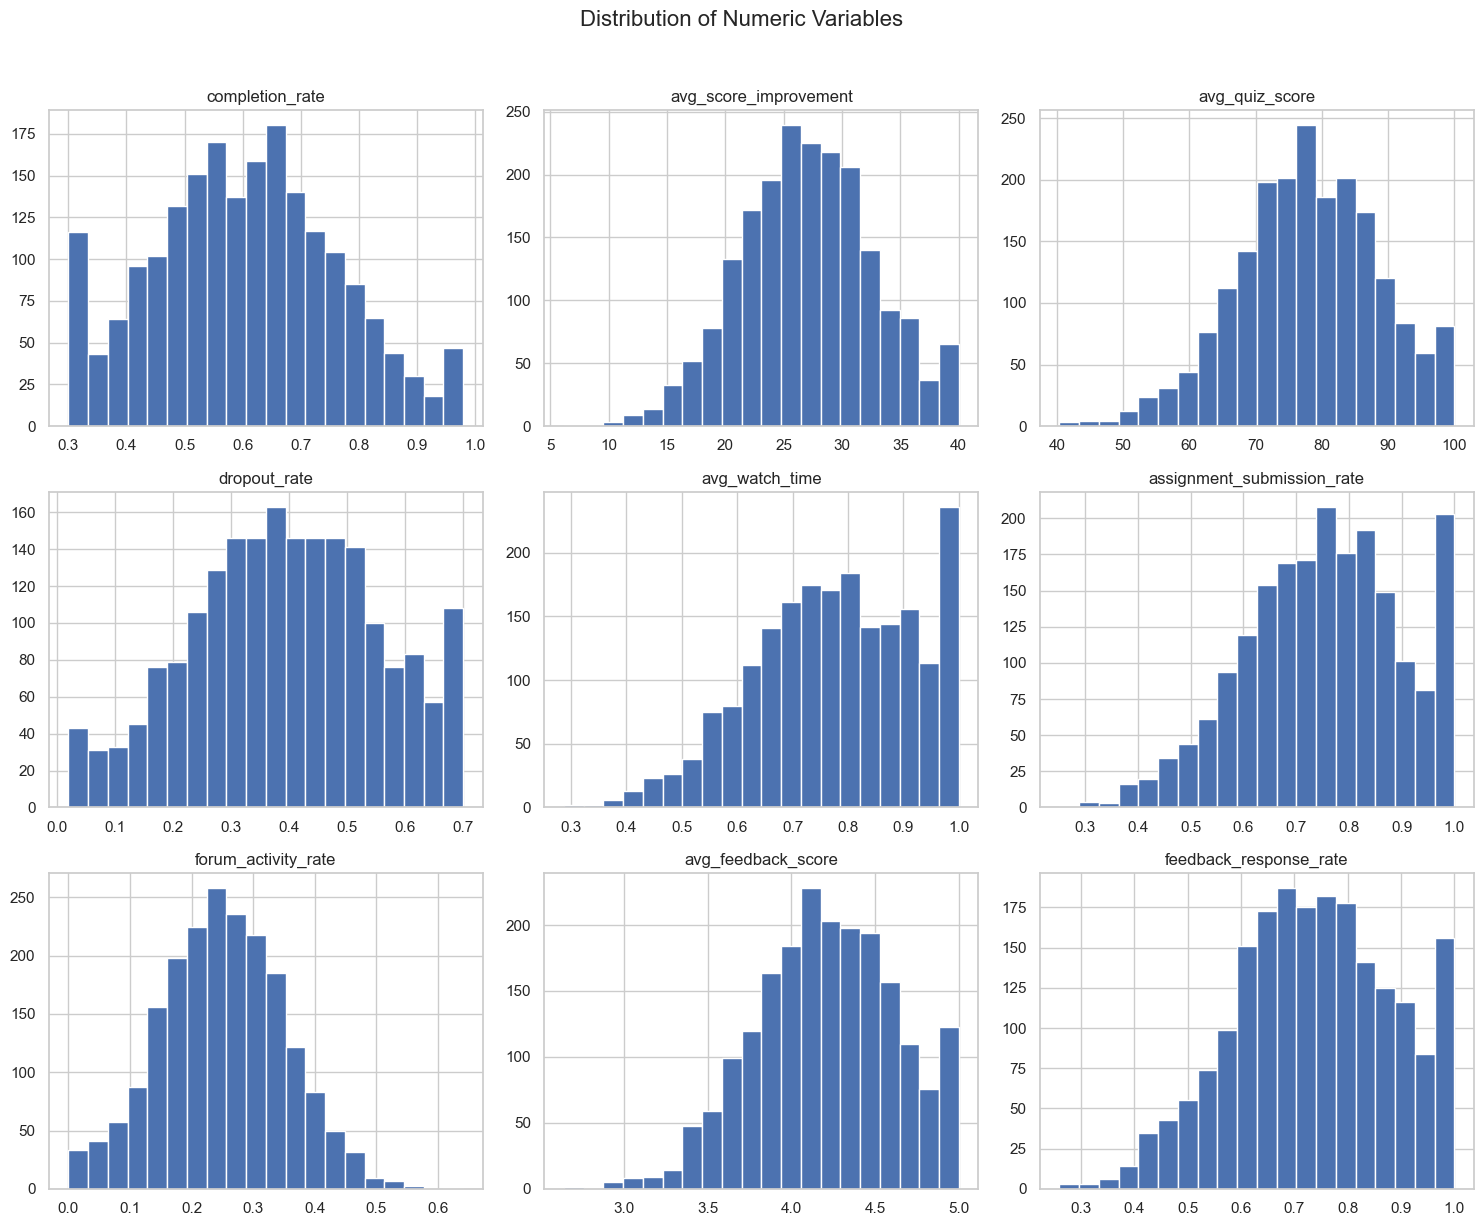

In [8]:
numeric_columns = df.select_dtypes(include=np.number).columns

df[numeric_columns].hist(
    figsize=(15, 12),
    bins=20
)

plt.suptitle(
    "Distribution of Numeric Variables",
    fontsize=16,
    y=1.02
)

plt.tight_layout()
plt.show()

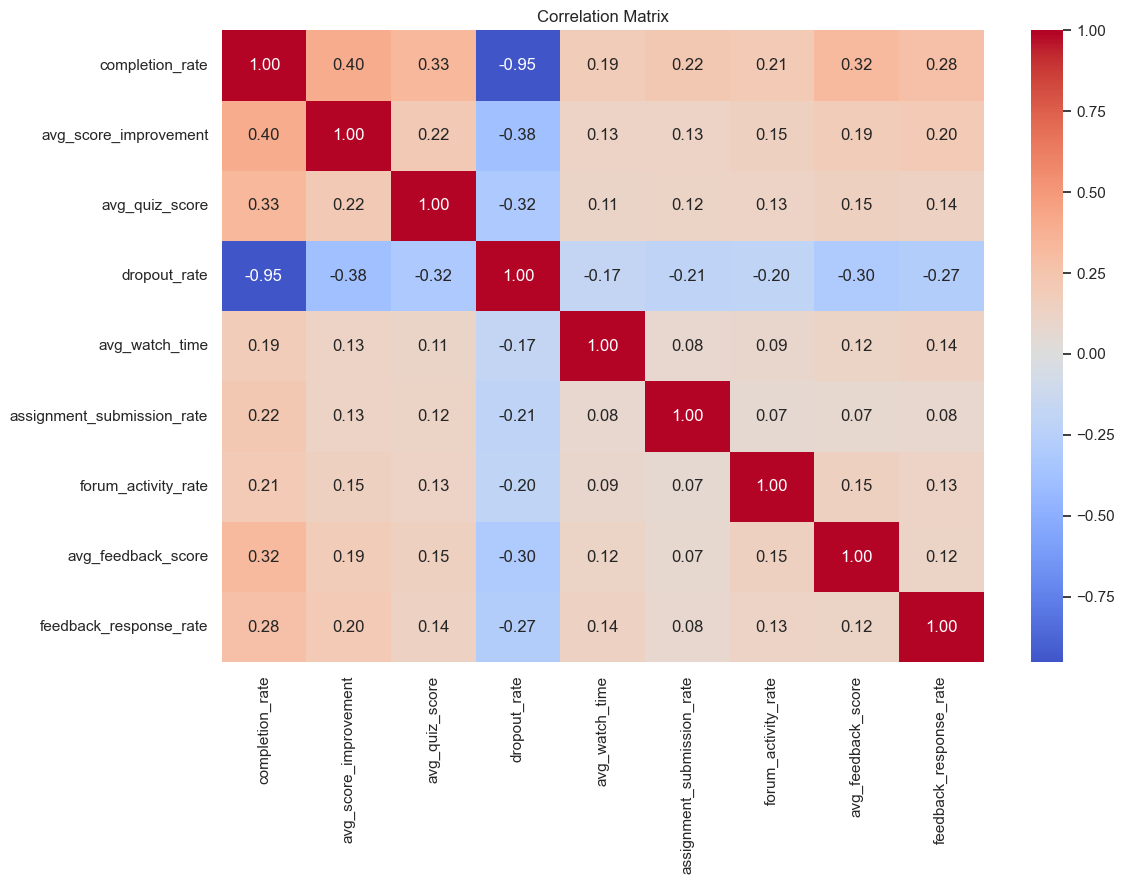

In [9]:
correlation_matrix = df[numeric_columns].corr()

plt.figure(figsize=(12, 9))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()


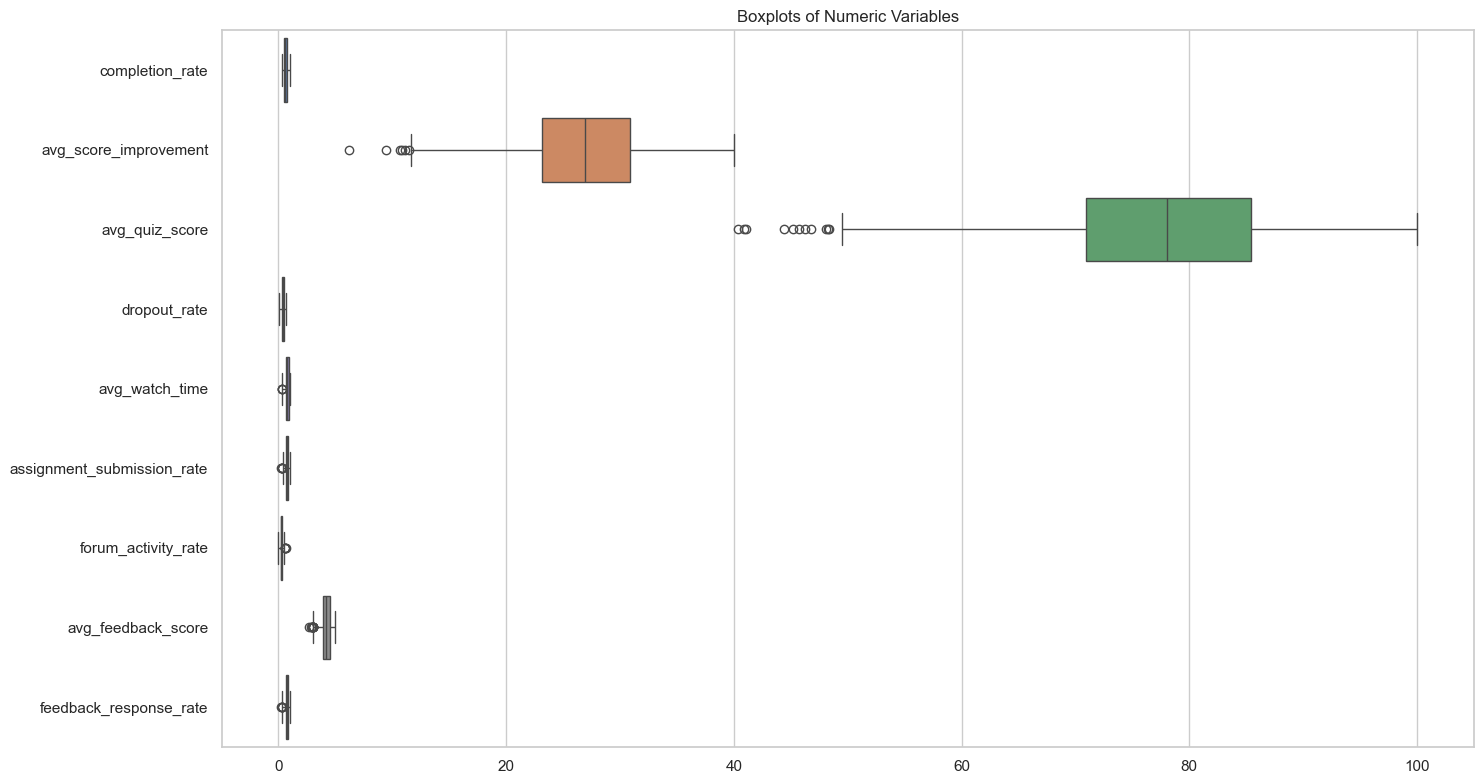

In [10]:
plt.figure(figsize=(15, 8))

sns.boxplot(
    data=df[numeric_columns],
    orient="h"
)

plt.title("Boxplots of Numeric Variables")
plt.tight_layout()
plt.show()

In [11]:
effectiveness_features = {
    "completion_rate": 1,
    "dropout_rate": -1,
    "avg_score_improvement": 1,
    "avg_quiz_score": 1,
    "avg_watch_time": 1,
    "assignment_submission_rate": 1,
    "forum_activity_rate": 1,
    "avg_feedback_score": 1,
    "feedback_response_rate": 1
}

component_columns = []

for column, direction in effectiveness_features.items():

    if column not in df.columns:
        print(f"Warning: {column} not found in dataset")
        continue

    min_value = df[column].min()
    max_value = df[column].max()

    if max_value == min_value:
        score = pd.Series(np.nan, index=df.index)

    else:
        score = (
            (df[column] - min_value) /
            (max_value - min_value)
        )

        # Reverse dropout because lower dropout is better
        if direction == -1:
            score = 1 - score

    new_column = column + "_component"

    df[new_column] = score

    component_columns.append(new_column)


# Average all available components
df["batch_effectiveness_score"] = (
    df[component_columns]
    .mean(axis=1)
)

display(
    df[
        [
            "batch_id",
            "instructor_id",
            "batch_effectiveness_score"
        ] + component_columns
    ].head()
)

,batch_id,instructor_id,batch_effectiveness_score,completion_rate_component,dropout_rate_component,avg_score_improvement_component,avg_quiz_score_component,avg_watch_time_component,assignment_submission_rate_component,forum_activity_rate_component,avg_feedback_score_component,feedback_response_rate_component
0,B_1861,I_044,0.365773,0.000000,0.077319,0.238373,0.556249,0.683637,0.720811,0.169103,0.477227,0.369235
1,B_0354,I_119,0.601158,0.525324,0.404268,0.493839,0.619419,0.291198,0.998085,0.437599,1.000000,0.640690
2,B_1334,I_050,0.436275,0.000000,0.000000,0.293382,0.657185,0.968987,0.742683,0.322898,0.371797,0.569542
3,B_0906,I_024,0.653135,0.499274,0.537269,0.534901,0.988179,0.784601,0.391839,0.477913,0.664240,1.000000
4,B_1290,I_001,0.641033,0.334267,0.263089,0.736459,0.989825,0.884150,0.820915,0.393519,0.756886,0.590184


count    2000.000000
mean        0.577375
std         0.109212
min         0.190834
25%         0.502764
50%         0.579528
75%         0.649028
max         0.912888
Name: batch_effectiveness_score, dtype: float64

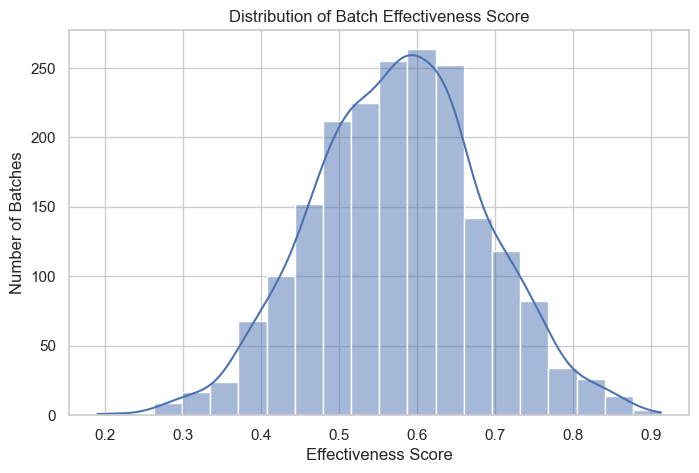

In [12]:
display(
    df["batch_effectiveness_score"]
    .describe()
)

plt.figure(figsize=(8, 5))

sns.histplot(
    df["batch_effectiveness_score"],
    bins=20,
    kde=True
)

plt.title("Distribution of Batch Effectiveness Score")
plt.xlabel("Effectiveness Score")
plt.ylabel("Number of Batches")

plt.show()

In [13]:
base_features = [
    column
    for column in effectiveness_features
    if column in df.columns
]

aggregation_dictionary = {
    column: ["mean", "median"]
    for column in base_features
}

aggregation_dictionary["batch_effectiveness_score"] = [
    "mean",
    "median",
    "std"
]

instructor_df = (
    df
    .groupby("instructor_id")
    .agg(aggregation_dictionary)
)

# Flatten multi-level column names
instructor_df.columns = [
    f"{first}_{second}"
    for first, second in instructor_df.columns
]

instructor_df = instructor_df.reset_index()


# Count number of batches per instructor
batch_counts = (
    df.groupby("instructor_id")["batch_id"]
    .nunique()
    .reset_index(name="batch_count")
)

instructor_df = instructor_df.merge(
    batch_counts,
    on="instructor_id",
    how="left"
)

# If an instructor has only one batch,
# standard deviation becomes NaN.
instructor_df[
    "batch_effectiveness_score_std"
] = instructor_df[
    "batch_effectiveness_score_std"
].fillna(0)

print("Instructor-level dataset shape:")
print(instructor_df.shape)

display(instructor_df.head())

Instructor-level dataset shape:
(120, 23)


,instructor_id,completion_rate_mean,completion_rate_median,dropout_rate_mean,dropout_rate_median,avg_score_improvement_mean,avg_score_improvement_median,avg_quiz_score_mean,avg_quiz_score_median,avg_watch_time_mean,avg_watch_time_median,assignment_submission_rate_mean,assignment_submission_rate_median,forum_activity_rate_mean,forum_activity_rate_median,avg_feedback_score_mean,avg_feedback_score_median,feedback_response_rate_mean,feedback_response_rate_median,batch_effectiveness_score_mean,batch_effectiveness_score_median,batch_effectiveness_score_std,batch_count
0,I_001,0.543887,0.545357,0.470593,0.471357,26.641462,26.112106,78.900194,78.961710,0.766513,0.733658,0.726893,0.738582,0.240551,0.251056,4.217743,4.249951,0.694858,0.655761,0.542935,0.521984,0.071970,25
1,I_002,0.730874,0.723018,0.247194,0.254720,30.166242,30.453036,81.737198,77.930867,0.837393,0.853840,0.774394,0.762905,0.289610,0.287592,4.343002,4.246529,0.784338,0.795214,0.672786,0.657918,0.064236,20
2,I_003,0.768447,0.754272,0.234828,0.234093,29.977813,29.786063,81.590928,83.114009,0.818441,0.825693,0.779606,0.757713,0.296224,0.304923,4.450034,4.429999,0.812132,0.773348,0.688231,0.698548,0.071925,18
3,I_004,0.458328,0.431807,0.547261,0.552827,22.912021,21.240292,77.680317,75.573381,0.793130,0.785699,0.758317,0.748872,0.226259,0.229930,4.076410,4.056810,0.721460,0.694328,0.505584,0.487236,0.067017,17
4,I_005,0.859747,0.871484,0.145733,0.103964,32.588652,32.768176,85.828159,86.624262,0.847026,0.871003,0.876942,0.864285,0.333519,0.328823,4.202516,4.223685,0.784197,0.794441,0.743692,0.740772,0.064711,19


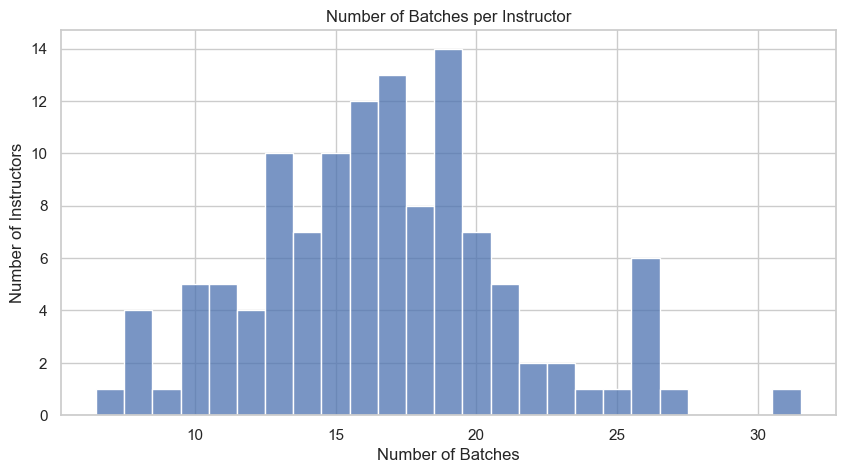

In [14]:
plt.figure(figsize=(10, 5))

sns.histplot(
    instructor_df["batch_count"],
    bins=15,
    discrete=True
)

plt.title("Number of Batches per Instructor")
plt.xlabel("Number of Batches")
plt.ylabel("Number of Instructors")

plt.show()

In [15]:
score_column = "batch_effectiveness_score_median"

instructor_df["effectiveness_tier"] = pd.qcut(
    instructor_df[score_column],
    q=3,
    labels=["Low", "Medium", "High"],
    duplicates="drop"
)

print("Effectiveness Tier Distribution:")

display(
    instructor_df["effectiveness_tier"]
    .value_counts()
    .sort_index()
)

Effectiveness Tier Distribution:


effectiveness_tier
Low       40
Medium    40
High      40
Name: count, dtype: int64

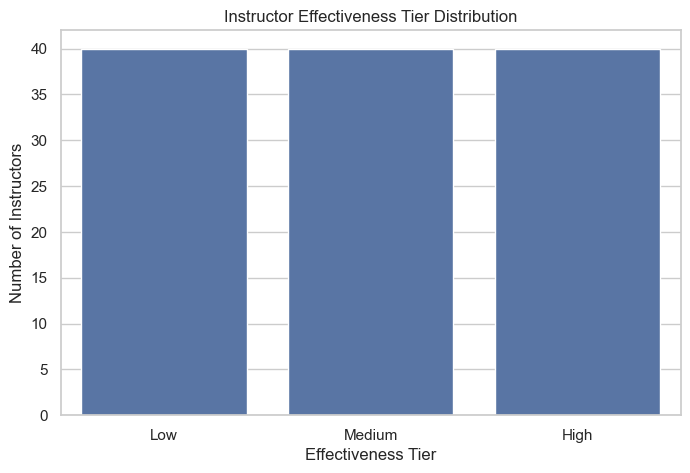

In [16]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=instructor_df,
    x="effectiveness_tier",
    order=["Low", "Medium", "High"]
)

plt.title("Instructor Effectiveness Tier Distribution")
plt.xlabel("Effectiveness Tier")
plt.ylabel("Number of Instructors")

plt.show()

In [17]:
tier_summary = (
    instructor_df
    .groupby("effectiveness_tier", observed=True)[
        [
            "batch_effectiveness_score_mean",
            "batch_effectiveness_score_median",
            "batch_count"
        ]
    ]
    .mean()
)

display(tier_summary)

,batch_effectiveness_score_mean,batch_effectiveness_score_median,batch_count
effectiveness_tier,,,
Low,0.477701,0.475826,16.300
Medium,0.576314,0.574695,16.875
High,0.675827,0.680817,16.825


In [18]:
feature_columns = []

# Mean features
for column in base_features:
    mean_column = f"{column}_mean"

    if mean_column in instructor_df.columns:
        feature_columns.append(mean_column)


# Median features
for column in base_features:
    median_column = f"{column}_median"

    if median_column in instructor_df.columns:
        feature_columns.append(median_column)


# Consistency + experience/evidence
feature_columns.extend([
    "batch_effectiveness_score_std",
    "batch_count"
])

print("Features used for ML:")
for feature in feature_columns:
    print("-", feature)

Features used for ML:
- completion_rate_mean
- dropout_rate_mean
- avg_score_improvement_mean
- avg_quiz_score_mean
- avg_watch_time_mean
- assignment_submission_rate_mean
- forum_activity_rate_mean
- avg_feedback_score_mean
- feedback_response_rate_mean
- completion_rate_median
- dropout_rate_median
- avg_score_improvement_median
- avg_quiz_score_median
- avg_watch_time_median
- assignment_submission_rate_median
- forum_activity_rate_median
- avg_feedback_score_median
- feedback_response_rate_median
- batch_effectiveness_score_std
- batch_count


In [19]:
model_df = instructor_df.dropna(
    subset=["effectiveness_tier"]
).copy()

X = model_df[feature_columns]

y = model_df["effectiveness_tier"].astype(str)

print("X Shape:", X.shape)
print("y Shape:", y.shape)

print("\nTarget Distribution:")
display(y.value_counts())

X Shape: (120, 20)
y Shape: (120,)

Target Distribution:


effectiveness_tier
Low       40
High      40
Medium    40
Name: count, dtype: int64

In [20]:
# Check that every class has enough observations
print(y.value_counts())

if y.value_counts().min() < 2:
    raise ValueError(
        "Each effectiveness tier needs at least 2 instructors "
        "for stratified train/test splitting."
    )

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

effectiveness_tier
Low       40
High      40
Medium    40
Name: count, dtype: int64
Training samples: 90
Testing samples: 30


In [21]:
model = Pipeline([
    
    # Handle missing values
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),

    # Standardize features
    (
        "scaler",
        StandardScaler()
    ),

    # Multiclass Logistic Regression
    (
        "classifier",
        LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=42
        )
    )
])

model.fit(
    X_train,
    y_train
)

y_pred = model.predict(X_test)

print("Model training completed.")

Model training completed.


In [22]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

evaluation_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Weighted Precision",
        "Weighted Recall",
        "Weighted F1"
    ],

    "Score": [
        accuracy,
        precision,
        recall,
        f1
    ]
})

display(evaluation_results)

,Metric,Score
0,Accuracy,0.833333
1,Weighted Precision,0.867133
2,Weighted Recall,0.833333
3,Weighted F1,0.828330


In [23]:
print("Classification Report:\n")

print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0
    )
)

Classification Report:

              precision    recall  f1-score   support

        High       1.00      0.60      0.75        10
         Low       0.91      1.00      0.95        10
      Medium       0.69      0.90      0.78        10

    accuracy                           0.83        30
   macro avg       0.87      0.83      0.83        30
weighted avg       0.87      0.83      0.83        30



## Model Evaluation

The Logistic Regression model achieved an **accuracy of 83.3%**, with a **weighted precision of 86.7%**, **weighted recall of 83.3%**, and **weighted F1-score of 82.8%**.

The model performed particularly well for the **Low** effectiveness tier, achieving a recall of 1.00 and an F1-score of 0.95. The **Medium** tier also achieved a strong recall of 0.90.

The **High** tier had a precision of 1.00 but a recall of 0.60. This means that when the model predicted an instructor as High effectiveness, the prediction was usually correct, but the model failed to identify some instructors who were actually in the High tier.

Overall, the model provides a reasonable baseline for predicting instructor effectiveness tiers. Since the evaluation set contains 10 observations from each tier, the test set is balanced across the three classes.

However, the dataset is relatively small, and the effectiveness target was constructed from the available learner outcome, engagement, and feedback variables. Therefore, the model should be treated as a structured analytical tool rather than a definitive measure of instructor quality.

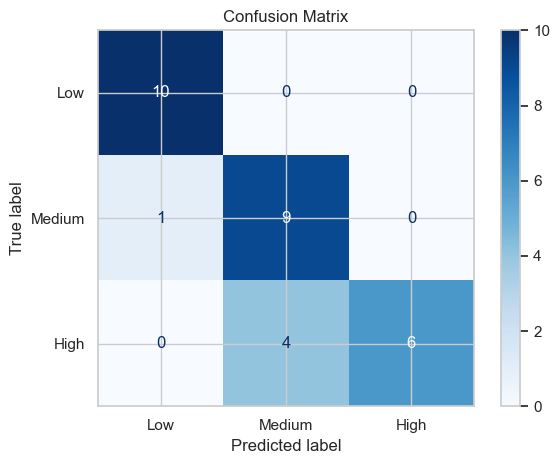

In [24]:
labels = [
    "Low",
    "Medium",
    "High"
]

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=labels
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

In [25]:
permutation = permutation_importance(
    model,
    X_test,
    y_test,
    scoring="f1_weighted",
    n_repeats=20,
    random_state=42
)

importance_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance Mean": permutation.importances_mean,
    "Importance Std": permutation.importances_std
})

importance_df = importance_df.sort_values(
    "Importance Mean",
    ascending=False
)

display(importance_df)

,Feature,Importance Mean,Importance Std
8,feedback_response_rate_mean,0.071253,0.048704
0,completion_rate_mean,0.067571,0.051002
5,assignment_submission_rate_mean,0.064902,0.043443
2,avg_score_improvement_mean,0.053229,0.038262
1,dropout_rate_mean,0.050877,0.042683
3,avg_quiz_score_mean,0.048627,0.052203
6,forum_activity_rate_mean,0.043016,0.029618
10,dropout_rate_median,0.036002,0.030995
14,assignment_submission_rate_median,0.031986,0.013430
9,completion_rate_median,0.030014,0.038465


## Feature Importance Interpretation

The permutation importance analysis shows that **feedback response rate, completion rate, and assignment submission rate** were the most influential features for predicting instructor effectiveness tiers.

Feedback response rate had the highest importance, suggesting that instructors whose learners were more likely to provide feedback were associated with different effectiveness tiers. Completion rate was also highly influential, which is reasonable because successful course completion is an important learner outcome.

Assignment submission rate and average score improvement were also among the stronger predictors. These variables capture learner participation and academic progress, respectively.

Dropout rate and average quiz score also contributed meaningfully to the predictions. In contrast, several median-based features had relatively low importance, suggesting that the model benefited more from the average performance across an instructor's batches.

Batch count had slightly negative permutation importance, while batch-level effectiveness variability had almost zero importance. This indicates that these features did not provide much additional predictive information in this particular dataset.

However, feature importance should not be interpreted as causation. For example, feedback response rate may reflect learner engagement or course characteristics rather than instructor effectiveness alone.

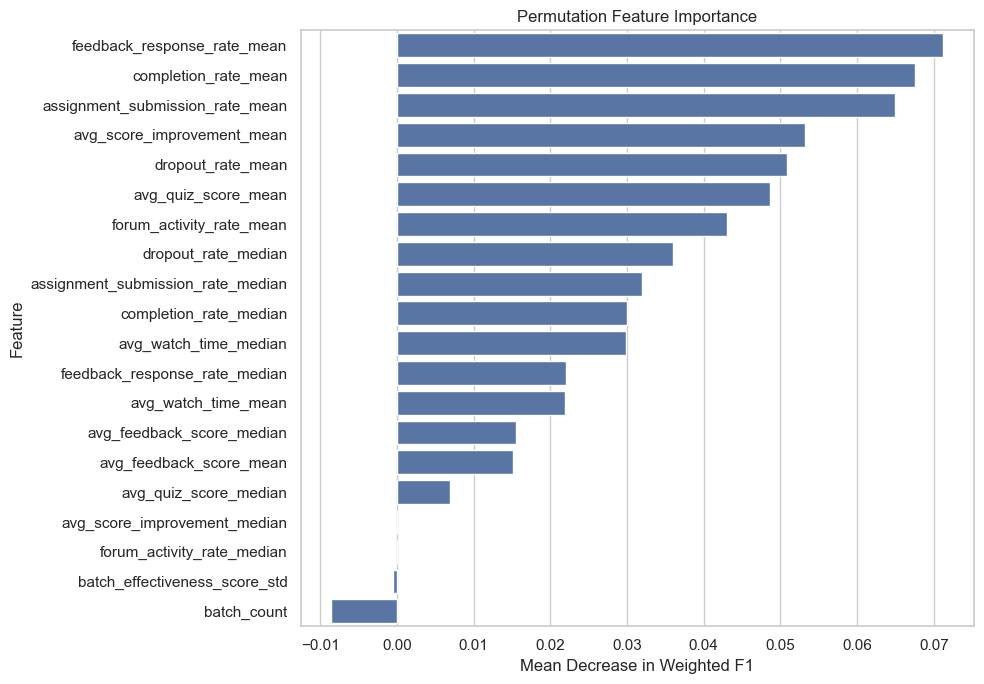

In [26]:
plt.figure(figsize=(10, 7))

sns.barplot(
    data=importance_df,
    x="Importance Mean",
    y="Feature"
)

plt.title(
    "Permutation Feature Importance"
)

plt.xlabel(
    "Mean Decrease in Weighted F1"
)

plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [27]:
display(
    instructor_df[
        [
            "instructor_id",
            "batch_count",
            "batch_effectiveness_score_mean",
            "batch_effectiveness_score_median",
            "batch_effectiveness_score_std",
            "effectiveness_tier"
        ]
    ]
    .sort_values(
        "batch_effectiveness_score_median",
        ascending=False
    )
    .head(20)
)

,instructor_id,batch_count,batch_effectiveness_score_mean,batch_effectiveness_score_median,batch_effectiveness_score_std,effectiveness_tier
9,I_010,13,0.822881,0.843916,0.050645,High
17,I_018,14,0.773142,0.787569,0.073529,High
36,I_037,15,0.796036,0.783317,0.049096,High
104,I_105,16,0.765122,0.764286,0.051241,High
90,I_091,8,0.752049,0.748888,0.060163,High
24,I_025,19,0.723549,0.748337,0.061039,High
4,I_005,19,0.743692,0.740772,0.064711,High
117,I_118,19,0.732397,0.730668,0.069869,High
12,I_013,17,0.702685,0.724497,0.059274,High
29,I_030,16,0.683968,0.704982,0.054397,High


## Mandatory Analysis Questions

### 1. Which features most influenced instructor effectiveness, and why?

Based on the permutation importance results, **feedback response rate, completion rate, and assignment submission rate** were the most influential features in predicting instructor effectiveness tiers.

Feedback response rate had the highest importance, followed by completion rate and assignment submission rate. Average score improvement, dropout rate, and average quiz score were also relatively influential.

These results are reasonable because completion and assignment submission reflect learner participation and persistence, while score improvement and quiz scores reflect learner progress. Feedback response rate provides an additional indication of learner engagement.

However, feature importance should not be interpreted as causation. These variables may also be influenced by learner motivation, course difficulty, course design, and other factors outside the instructor's control.


### 2. Which variables could be misleading or confounded?

Several variables may be influenced by factors other than instructor effectiveness. For example, **completion rate and dropout rate** may depend on learner motivation, prior knowledge, or personal circumstances. **Quiz scores and score improvement** may be affected by assessment difficulty and the initial ability of learners.

Similarly, **watch time and assignment submission rate** may depend on course structure and workload. **Feedback-related variables** may be influenced by learner engagement and willingness to provide feedback.

Therefore, these variables should be interpreted as indicators associated with instructor effectiveness rather than direct measures of teaching quality.


### 3. How could this model fail in real-world usage?

The model could incorrectly rate instructors if they teach courses with different levels of difficulty or receive substantially different learner populations.

An instructor with only a small number of batches may also have an unstable effectiveness estimate. The model may additionally reflect historical patterns or biases present in the data.

Another important limitation is that the model identifies associations rather than proving that the instructor caused the observed learner outcomes.


### 4. What additional data would you want to improve this analysis?

I would want additional information such as **learner pre-assessment scores, course difficulty, learner attendance, class size, course duration, instructor experience, assessment difficulty, learner historical performance, assignment quality, and longitudinal learner outcomes**.

Pre-assessment scores would be particularly useful because they would help distinguish between learner improvement caused by the course/instruction and outcomes that may simply reflect differences in the starting ability of learners.


### 5. Should this model be used for instructor performance evaluation?

The model **should not be used as the sole basis for instructor performance evaluation**.

It would be more appropriate as a decision-support tool for identifying patterns, recognizing potentially effective teaching practices, and identifying instructors who may benefit from additional support.

Human review is important because learner outcomes can be influenced by many factors outside an instructor's control. High-stakes decisions such as compensation, promotion, or termination should not rely solely on this model.

## Final Conclusion

This analysis defines instructor effectiveness using a combination of learner outcomes, engagement, and feedback. Batch-level data was aggregated to the instructor level using mean, median, consistency, and batch-count measures, and instructors were classified into Low, Medium, and High effectiveness tiers.

A multiclass Logistic Regression model was developed to predict these effectiveness tiers. The model achieved **83.3% accuracy and a weighted F1-score of 82.8%**, providing a reasonable baseline for identifying instructor effectiveness patterns.

Permutation importance showed that **feedback response rate, completion rate, and assignment submission rate** were among the most influential features, followed by score improvement, dropout rate, and quiz performance. These results suggest that learner engagement and outcomes are important indicators associated with instructor effectiveness.

However, these metrics should not be interpreted as direct or causal measures of teaching quality. Learner motivation, prior ability, course difficulty, assessment design, and other contextual factors can influence the observed outcomes.

Therefore, this model should be used primarily as a **decision-support tool** to identify trends, recognize potentially effective practices, and identify areas where instructors may benefit from support. It should not be used as the sole basis for high-stakes instructor performance decisions.